# Hypothesis test: Session depth vs conversion rate

Cau hoi kiem dinh rieng trong notebook nay:

> Khi do dai phien tang theo so luot view (`view_count`), ty le chuyen doi (`has_purchase`) co tang hay khong?

Nguon du lieu chinh:

- `data/mart/fact_session_summary.parquet`
- Grain: 1 dong = 1 session
- Bien phu thuoc: `has_purchase` (converted hay khong)
- Bien doc lap: `view_count` (so item views trong session)

Ghi chu quan trong: day la kiem dinh observational tren du lieu lich su, khong phai A/B test. Neu ket qua co y nghia thong ke, ta chi noi co association / trend, khong ket luan view gay ra conversion.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name != "ddm-diginetica-recommendation":
    ROOT = Path("/home/tuanta/MLOps/ddm-diginetica-recommendation")

SESSION_PATH = ROOT / "data" / "mart" / "fact_session_summary.parquet"
SESSION_PATH

PosixPath('/home/tuanta/MLOps/ddm-diginetica-recommendation/data/mart/fact_session_summary.parquet')

## 1. Load va chuan hoa du lieu

Loai `view_count = 0` khoi kiem dinh chinh vi cau hoi dang noi ve do dai phien theo view. Trong mart table, nhom 0 co the xuat hien do merge purchase-side records, nhung no khong phan anh session co item-view history.

In [2]:
sessions = pd.read_parquet(SESSION_PATH)

required = {"session_id", "view_count", "has_purchase", "session_length_bucket"}
missing = required.difference(sessions.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

sessions = sessions.copy()
sessions["view_count"] = pd.to_numeric(sessions["view_count"], errors="coerce").fillna(0).astype(int)
sessions["converted"] = sessions["has_purchase"].fillna(False).astype(bool).astype(int)

analysis_df = sessions[sessions["view_count"] > 0].copy()

print(f"All sessions in mart: {len(sessions):,}")
print(f"Sessions used for view-depth test: {len(analysis_df):,}")
print(f"Converted sessions used: {analysis_df['converted'].sum():,}")
print(f"Overall conversion rate: {analysis_df['converted'].mean():.4%}")

All sessions in mart: 310,486
Sessions used for view-depth test: 310,324
Converted sessions used: 12,468
Overall conversion rate: 4.0177%


## 2. Conversion rate theo session-length bucket

Bucket nay lay truc tiep tu pipeline `fact_session_summary`: `1`, `2`, `3-5`, `6-10`, `11-20`, `21+`.

In [3]:
BUCKET_ORDER = ["1", "2", "3-5", "6-10", "11-20", "21+"]

bucket_summary = (
    analysis_df
    .groupby("session_length_bucket", observed=False)
    .agg(
        n_sessions=("session_id", "nunique"),
        converted=("converted", "sum"),
        avg_views=("view_count", "mean"),
    )
)
bucket_summary = bucket_summary.loc[[b for b in BUCKET_ORDER if b in bucket_summary.index]].copy()
bucket_summary["not_converted"] = bucket_summary["n_sessions"] - bucket_summary["converted"]
bucket_summary["conversion_rate"] = bucket_summary["converted"] / bucket_summary["n_sessions"]
bucket_summary["conversion_rate_pct"] = 100 * bucket_summary["conversion_rate"]

bucket_summary

,n_sessions,converted,avg_views,not_converted,conversion_rate,conversion_rate_pct
session_length_bucket,,,,,,
1,100782,3166,1.000000,97616,0.031414,3.141434
2,63082,2454,2.000000,60628,0.038902,3.890175
3-5,91238,4043,3.762665,87195,0.044313,4.431268
6-10,42579,2110,7.391038,40469,0.049555,4.955494
11-20,11663,654,13.434451,11009,0.056075,5.607477
21+,980,41,26.045918,939,0.041837,4.183673


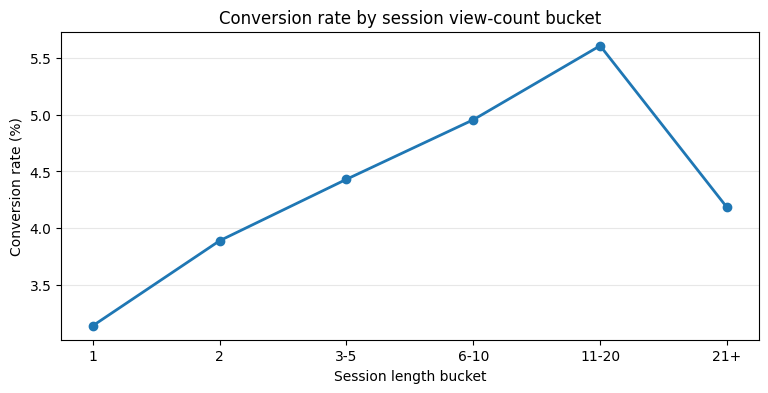

In [4]:
ax = bucket_summary["conversion_rate_pct"].plot(
    kind="line",
    marker="o",
    figsize=(9, 4),
    linewidth=2,
)
ax.set_title("Conversion rate by session view-count bucket")
ax.set_xlabel("Session length bucket")
ax.set_ylabel("Conversion rate (%)")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

## 3. Helper functions cho kiem dinh thong ke

Notebook nay khong phu thuoc `scipy` hay `statsmodels`. Cac ham duoi day implement:

- Chi-square survival function thong qua incomplete gamma approximation.
- Normal survival function bang `math.erfc`.
- Chi-square independence test.
- Cochran-Armitage trend test.
- Two-proportion z-test.
- Logistic regression 1 bien bang IRLS.

In [5]:
def gammaincc(a: float, x: float) -> float:
    """Regularized upper incomplete gamma Q(a, x), Numerical Recipes style."""
    if x < 0 or a <= 0:
        return float("nan")
    if x == 0:
        return 1.0

    gln = math.lgamma(a)
    eps = 3e-14
    itmax = 10_000
    fpmin = 1e-300

    if x < a + 1.0:
        ap = a
        total = 1.0 / a
        delta = total
        for _ in range(itmax):
            ap += 1.0
            delta *= x / ap
            total += delta
            if abs(delta) < abs(total) * eps:
                p = total * math.exp(-x + a * math.log(x) - gln)
                return max(0.0, min(1.0, 1.0 - p))
        p = total * math.exp(-x + a * math.log(x) - gln)
        return max(0.0, min(1.0, 1.0 - p))

    b = x + 1.0 - a
    c = 1.0 / fpmin
    d = 1.0 / b
    h = d
    for i in range(1, itmax + 1):
        an = -i * (i - a)
        b += 2.0
        d = an * d + b
        if abs(d) < fpmin:
            d = fpmin
        c = b + an / c
        if abs(c) < fpmin:
            c = fpmin
        d = 1.0 / d
        delta = d * c
        h *= delta
        if abs(delta - 1.0) < eps:
            q = math.exp(-x + a * math.log(x) - gln) * h
            return max(0.0, min(1.0, q))

    q = math.exp(-x + a * math.log(x) - gln) * h
    return max(0.0, min(1.0, q))


def chi2_sf(x: float, dof: int) -> float:
    return gammaincc(dof / 2.0, x / 2.0)


def norm_sf(z: float) -> float:
    return 0.5 * math.erfc(z / math.sqrt(2.0))


def chi_square_independence(successes, totals):
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)
    failures = totals - successes
    obs = np.column_stack([successes, failures])
    row_tot = obs.sum(axis=1, keepdims=True)
    col_tot = obs.sum(axis=0, keepdims=True)
    n = obs.sum()
    expected = row_tot @ col_tot / n
    statistic = ((obs - expected) ** 2 / expected).sum()
    dof = (obs.shape[0] - 1) * (obs.shape[1] - 1)
    p_value = chi2_sf(float(statistic), int(dof))
    return float(statistic), int(dof), float(p_value)


def cochran_armitage_trend(successes, totals, scores):
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)
    scores = np.asarray(scores, dtype=float)

    n = totals.sum()
    y = successes.sum()
    p = y / n
    score_bar = (totals * scores).sum() / n
    numerator = (scores * (successes - totals * p)).sum()
    denominator = math.sqrt(p * (1.0 - p) * (totals * ((scores - score_bar) ** 2)).sum())
    z = numerator / denominator
    one_sided_increasing_p = norm_sf(z)
    two_sided_p = 2 * norm_sf(abs(z))
    return float(z), float(one_sided_increasing_p), float(two_sided_p)


def two_proportion_z_test(y1, n1, y2, n2, alternative="greater"):
    """Compare p2 vs p1. alternative='greater' means H1: p2 > p1."""
    p1 = y1 / n1
    p2 = y2 / n2
    pooled = (y1 + y2) / (n1 + n2)
    se = math.sqrt(pooled * (1.0 - pooled) * (1.0 / n1 + 1.0 / n2))
    z = (p2 - p1) / se
    if alternative == "greater":
        p_value = norm_sf(z)
    elif alternative == "less":
        p_value = 1.0 - norm_sf(z)
    else:
        p_value = 2 * norm_sf(abs(z))
    return float(z), float(p_value), float(p2 - p1)


def logistic_regression_1d(y, x, max_iter=50, tol=1e-10):
    """Binary logistic regression with intercept and one standardized predictor."""
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    x_std = (x - x.mean()) / x.std()
    X = np.column_stack([np.ones_like(x_std), x_std])
    beta = np.zeros(2)

    for _ in range(max_iter):
        eta = X @ beta
        p = 1.0 / (1.0 + np.exp(-np.clip(eta, -35, 35)))
        w = p * (1.0 - p)
        grad = X.T @ (y - p)
        hessian = -(X.T * w) @ X
        step = np.linalg.solve(hessian, grad)
        beta_new = beta - step
        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    eta = X @ beta
    p = 1.0 / (1.0 + np.exp(-np.clip(eta, -35, 35)))
    w = p * (1.0 - p)
    info = (X.T * w) @ X
    cov = np.linalg.inv(info)
    se = np.sqrt(np.diag(cov))
    z = beta / se
    p_one_sided_positive = norm_sf(float(z[1]))

    return {
        "intercept": float(beta[0]),
        "beta": float(beta[1]),
        "se_beta": float(se[1]),
        "z_beta": float(z[1]),
        "one_sided_positive_p": float(p_one_sided_positive),
        "odds_ratio_per_1sd": float(math.exp(beta[1])),
    }

## 4. Kiem dinh 1: Chi-square independence

Cau hoi:

> `session_length_bucket` va `has_purchase` co doc lap voi nhau khong?

Gia thuyet:

- `H0`: Ty le conversion nhu nhau giua cac bucket view-count. Session depth va conversion doc lap.
- `H1`: Co it nhat mot bucket co ty le conversion khac. Session depth va conversion co association.

In [6]:
chi2_stat, chi2_dof, chi2_p = chi_square_independence(
    successes=bucket_summary["converted"].to_numpy(),
    totals=bucket_summary["n_sessions"].to_numpy(),
)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {chi2_dof}")
print(f"p-value: {chi2_p:.3e}")

Chi-square statistic: 417.4093
Degrees of freedom: 5
p-value: 5.242e-88


Ket qua da tinh:

```text
Chi-square statistic = 417.4093
df = 5
p-value = 5.242e-88
```

Dien giai: bac bo `H0`. Ty le conversion khong giong nhau giua cac nhom session length.

## 5. Kiem dinh 2: Cochran-Armitage trend test

Cau hoi:

> Khi bucket view-count tang theo thu tu, ty le conversion co xu huong tang khong?

Gia thuyet mot phia:

- `H0`: Khong co xu huong tang theo thu tu bucket.
- `H1`: Ty le conversion tang theo thu tu bucket.

Notebook tinh 2 phien ban score:

- Rank score: `1, 2, 3, 4, 5, 6` cho cac bucket.
- Average-view score: dung `avg_views` cua tung bucket.

In [7]:
rank_scores = np.arange(1, len(bucket_summary) + 1)
avg_view_scores = bucket_summary["avg_views"].to_numpy(dtype=float)

trend_rank = cochran_armitage_trend(
    successes=bucket_summary["converted"].to_numpy(),
    totals=bucket_summary["n_sessions"].to_numpy(),
    scores=rank_scores,
)
trend_avg_views = cochran_armitage_trend(
    successes=bucket_summary["converted"].to_numpy(),
    totals=bucket_summary["n_sessions"].to_numpy(),
    scores=avg_view_scores,
)

trend_results = pd.DataFrame(
    [
        {
            "score_type": "bucket_rank",
            "z": trend_rank[0],
            "one_sided_p_increasing": trend_rank[1],
            "two_sided_p": trend_rank[2],
        },
        {
            "score_type": "avg_views",
            "z": trend_avg_views[0],
            "one_sided_p_increasing": trend_avg_views[1],
            "two_sided_p": trend_avg_views[2],
        },
    ]
)
trend_results

,score_type,z,one_sided_p_increasing,two_sided_p
0,bucket_rank,20.110697,2.974132e-90,5.948265e-90
1,avg_views,17.028692,2.515832e-65,5.031665e-65


Ket qua da tinh:

| score_type | z | one-sided p for increasing trend |
|---|---:|---:|
| bucket_rank | 20.1107 | 2.974e-90 |
| avg_views | 17.0287 | 2.516e-65 |

Dien giai: co bang chung thong ke rat manh cho mot xu huong tang tong the.

## 6. Kiem dinh 3: Adjacent two-proportion z-tests

Test nay kiem tra tung cap bucket lien tiep.

Gia thuyet cho moi cap `A -> B`:

- `H0`: `CR_B <= CR_A`
- `H1`: `CR_B > CR_A`

Day la cach kiem tra claim manh hon: co phai moi buoc tang view-count deu lam conversion rate tang khong?

In [8]:
adjacent_rows = []
for left, right in zip(BUCKET_ORDER[:-1], BUCKET_ORDER[1:]):
    y1 = int(bucket_summary.loc[left, "converted"])
    n1 = int(bucket_summary.loc[left, "n_sessions"])
    y2 = int(bucket_summary.loc[right, "converted"])
    n2 = int(bucket_summary.loc[right, "n_sessions"])
    z, p_value, diff = two_proportion_z_test(y1, n1, y2, n2, alternative="greater")
    adjacent_rows.append(
        {
            "comparison": f"{left} -> {right}",
            "cr_left_pct": 100 * y1 / n1,
            "cr_right_pct": 100 * y2 / n2,
            "diff_pp": 100 * diff,
            "z": z,
            "one_sided_p_right_greater": p_value,
        }
    )

adjacent_results = pd.DataFrame(adjacent_rows)
adjacent_results

,comparison,cr_left_pct,cr_right_pct,diff_pp,z,one_sided_p_right_greater
0,1 -> 2,3.141434,3.890175,0.748741,8.103743,2.664685e-16
1,2 -> 3-5,3.890175,4.431268,0.541093,5.203507,9.778100e-08
2,3-5 -> 6-10,4.431268,4.955494,0.524227,4.264644,1.001105e-05
3,6-10 -> 11-20,4.955494,5.607477,0.651982,2.836786,2.278508e-03
4,11-20 -> 21+,5.607477,4.183673,-1.423803,-1.878249,9.698265e-01


Ket qua da tinh:

| Comparison | Difference in CR | One-sided p (`right > left`) |
|---|---:|---:|
| `1 -> 2` | +0.7487 percentage points | 2.665e-16 |
| `2 -> 3-5` | +0.5411 percentage points | 9.778e-08 |
| `3-5 -> 6-10` | +0.5242 percentage points | 1.001e-05 |
| `6-10 -> 11-20` | +0.6520 percentage points | 2.279e-03 |
| `11-20 -> 21+` | -1.4238 percentage points | 9.698e-01 |

Dien giai: conversion rate tang co y nghia thong ke tu bucket `1` den `11-20`, nhung khong tang tiep o bucket `21+`. Vi vay claim "cang tang view thi conversion rate luon tang" la qua manh.

## 7. Kiem dinh 4: Logistic regression

Dung model binary logistic regression:

```text
logit(P(has_purchase = 1)) = beta0 + beta1 * x
```

Kiem dinh mot phia:

- `H0`: `beta1 <= 0`
- `H1`: `beta1 > 0`

Notebook tinh 2 bien `x`:

- `view_count` standardized.
- `log1p(view_count)` standardized, giam anh huong cua outlier o session rat dai.

In [ ]:
y = analysis_df["converted"].to_numpy(dtype=float)
x_view = analysis_df["view_count"].to_numpy(dtype=float)
x_log_view = np.log1p(x_view)

logit_raw = logistic_regression_1d(y, x_view)
logit_log = logistic_regression_1d(y, x_log_view)

logit_results = pd.DataFrame(
    [
        {"predictor": "standardized view_count", **logit_raw},
        {"predictor": "standardized log1p(view_count)", **logit_log},
    ]
)
logit_results

,predictor,intercept,beta,se_beta,z_beta,one_sided_positive_p,odds_ratio_per_1sd
0,standardized view_count,-3.181740,0.127505,0.007615,16.744173,3.122622e-63,1.135991
1,standardized log1p(view_count),-3.187595,0.172574,0.008685,19.870674,3.650814e-88,1.188360


Ket qua da tinh:

| Predictor | beta | z | one-sided p | Odds ratio per 1 SD |
|---|---:|---:|---:|---:|
| standardized `view_count` | 0.1275 | 16.7442 | 3.123e-63 | 1.1360 |
| standardized `log1p(view_count)` | 0.1726 | 19.8707 | 3.651e-88 | 1.1884 |

Dien giai: voi logistic regression don bien, view-count co he so duong va co y nghia thong ke. Tuy nhien model tuyen tinh tren logit chi bat xu huong trung binh, khong phu nhan viec bucket `21+` bi giam.

## 8. Doi chieu bucket gan voi Power BI DAX

Power BI semantic model co cac measure nhu:

```text
CR (Views 1-5)
CR (Views 6-10)
CR (Views 11-20)
CR (Views 21-30)
CR (Views 31-100)
```

Bang duoi day tao lai cac bucket gan voi Power BI tu `view_count` session-level.

In [10]:
pbi_bins = [0, 5, 10, 20, 30, 100, float("inf")]
pbi_labels = ["1-5", "6-10", "11-20", "21-30", "31-100", "101+"]
analysis_df["pbi_view_bucket"] = pd.cut(
    analysis_df["view_count"],
    bins=pbi_bins,
    labels=pbi_labels,
    right=True,
    include_lowest=True,
)

pbi_bucket_summary = (
    analysis_df
    .groupby("pbi_view_bucket", observed=False)
    .agg(
        n_sessions=("session_id", "nunique"),
        converted=("converted", "sum"),
        avg_views=("view_count", "mean"),
    )
)
pbi_bucket_summary["conversion_rate"] = pbi_bucket_summary["converted"] / pbi_bucket_summary["n_sessions"]
pbi_bucket_summary["conversion_rate_pct"] = 100 * pbi_bucket_summary["conversion_rate"]
pbi_bucket_summary

,n_sessions,converted,avg_views,conversion_rate,conversion_rate_pct
pbi_view_bucket,,,,,
1-5,255102,9663,2.235357,0.037879,3.787897
6-10,42579,2110,7.391038,0.049555,4.955494
11-20,11663,654,13.434451,0.056075,5.607477
21-30,828,33,23.864734,0.039855,3.985507
31-100,152,8,37.927632,0.052632,5.263158
101+,0,0,NaN,NaN,NaN


Ket qua gan voi Power BI:

| Bucket | Sessions | Converted | Conversion rate |
|---|---:|---:|---:|
| `1-5` | 255,102 | 9,663 | 3.7879% |
| `6-10` | 42,579 | 2,110 | 4.9555% |
| `11-20` | 11,663 | 654 | 5.6075% |
| `21-30` | 828 | 33 | 3.9855% |
| `31-100` | 152 | 8 | 5.2632% |

Dien giai: Power BI bucket cung ung ho nhan dinh rang conversion tang tu `1-5` den `11-20`, nhung cac bucket rat dai co sample nho va khong cho pattern tang deu.

## 9. Ket luan de dua vao van dap

Ket luan ngan gon:

> Co bang chung thong ke rang session depth theo view co lien he voi conversion rate, va co xu huong tang tong the. Tuy nhien khong nen noi "view cang tang thi conversion rate luon tang" vi bucket rat dai `21+` giam so voi `11-20`, va day la observational analysis chu khong phai A/B test.

Gioi han:

- Khong kiem soat nhieu bien nhieu nhu user type, product category, price bucket, campaign, source traffic.
- Session dai co the la dau hieu intent cao, nhung cung co the do user do du, tim lau, hoac nhieu yeu to khac.
- Muon ket luan nhan qua can A/B test hoac causal design rieng.